SVM Classifier:
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.8991596638655462
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       107
           1       0.92      0.89      0.91       131

    accuracy                           0.90       238
   macro avg       0.90      0.90      0.90       238
weighted avg       0.90      0.90      0.90       238



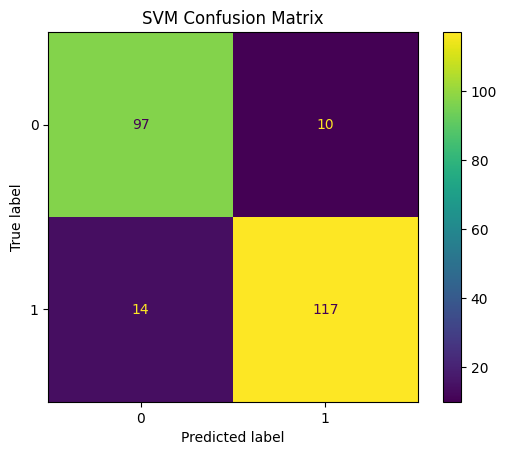

LogisticRegression Classifier:
Best Parameters: {'C': 1}
Accuracy: 0.8613445378151261
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       107
           1       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



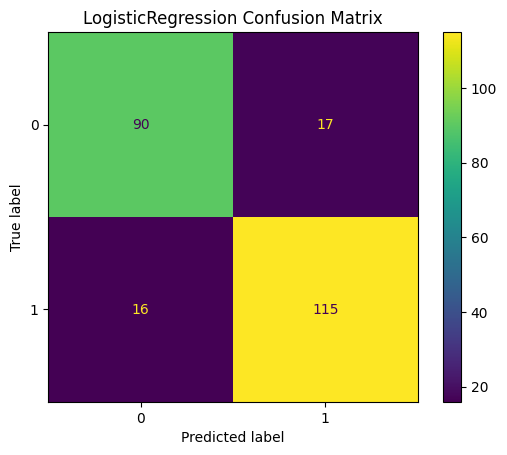

DecisionTree Classifier:
Best Parameters: {'criterion': 'gini', 'max_depth': 20}
Accuracy: 0.8949579831932774
              precision    recall  f1-score   support

           0       0.85      0.93      0.89       107
           1       0.93      0.87      0.90       131

    accuracy                           0.89       238
   macro avg       0.89      0.90      0.89       238
weighted avg       0.90      0.89      0.90       238



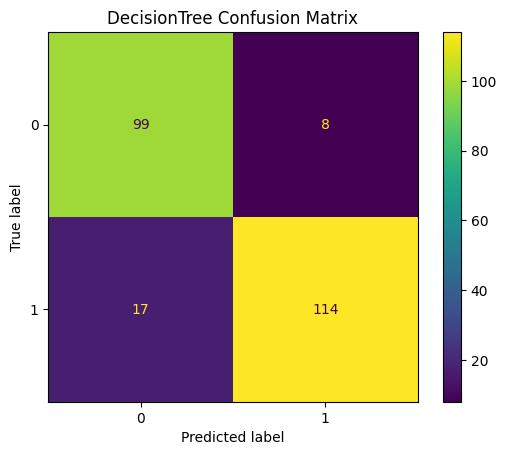

RandomForest Classifier:
Best Parameters: {'criterion': 'entropy', 'max_depth': 20, 'n_estimators': 50}
Accuracy: 0.9411764705882353
              precision    recall  f1-score   support

           0       0.93      0.93      0.93       107
           1       0.95      0.95      0.95       131

    accuracy                           0.94       238
   macro avg       0.94      0.94      0.94       238
weighted avg       0.94      0.94      0.94       238



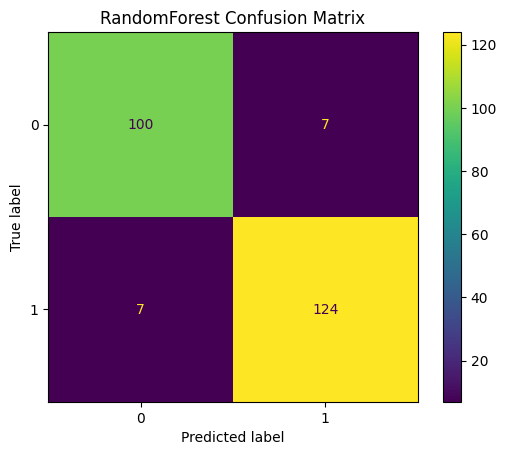

In [21]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt


data = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')
X = data.drop('target', axis=1)
y = data['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

models_params = {
    'SVM': {
        'model': SVC(),
        'params': {'kernel': ['linear', 'rbf'], 'C': [1, 10, 20]}
    },
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': {'C': [1, 5, 10]}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 20]}
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {'n_estimators': [10, 50, 100], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 20]}
    }
}


for name, mp in models_params.items():
    pipe = Pipeline(
        [
            ('scaler', StandardScaler()),
            (name, GridSearchCV(mp['model'], mp['params'], cv=5))
        ]
    )
    pipe.fit(X_train, y_train)


    predictions = pipe.predict(X_test)
    print(f"{name} Classifier:")
    print(f"Best Parameters: {pipe.named_steps[name].best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, predictions)}")
    print(classification_report(y_test, predictions))
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

In [22]:
import pandas as pd
data_check = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')
print(data_check.columns)

Index(['age', 'sex', 'chest pain type', 'resting bp s', 'cholesterol',
       'fasting blood sugar', 'resting ecg', 'max heart rate',
       'exercise angina', 'oldpeak', 'ST slope', 'target'],
      dtype='object')


In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')
X = data.drop('target', axis=1)
y = data['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


svm_classifier = SVC(kernel='linear')
log_reg_classifier = LogisticRegression()
decision_tree_classifier = DecisionTreeClassifier()
random_forest_classifier = RandomForestClassifier()


svm_classifier.fit(X_train, y_train)
log_reg_classifier.fit(X_train, y_train)
decision_tree_classifier.fit(X_train, y_train)
random_forest_classifier.fit(X_train, y_train)


svm_pred = svm_classifier.predict(X_test)
log_reg_pred = log_reg_classifier.predict(X_test)
decision_tree_pred = decision_tree_classifier.predict(X_test)
random_forest_pred = random_forest_classifier.predict(X_test)


print("SVM Classifier:")
print(f"Accuracy: {accuracy_score(y_test, svm_pred)}")
print(classification_report(y_test, svm_pred))
print(confusion_matrix(y_test, svm_pred))

print("\nLogistic Regression Classifier:")
print(f"Accuracy: {accuracy_score(y_test, log_reg_pred)}")
print(classification_report(y_test, log_reg_pred))
print(confusion_matrix(y_test, log_reg_pred))

print("\nDecision Tree Classifier:")
print(f"Accuracy: {accuracy_score(y_test, decision_tree_pred)}")
print(classification_report(y_test, decision_tree_pred))
print(confusion_matrix(y_test, decision_tree_pred))

print("\nRandom Forest Classifier:")
print(f"Accuracy: {accuracy_score(y_test, random_forest_pred)}")
print(classification_report(y_test, random_forest_pred))
print(confusion_matrix(y_test, random_forest_pred))

SVM Classifier:
Accuracy: 0.8445378151260504
              precision    recall  f1-score   support

           0       0.83      0.82      0.83       107
           1       0.86      0.86      0.86       131

    accuracy                           0.84       238
   macro avg       0.84      0.84      0.84       238
weighted avg       0.84      0.84      0.84       238

[[ 88  19]
 [ 18 113]]

Logistic Regression Classifier:
Accuracy: 0.8613445378151261
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       107
           1       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238

[[ 90  17]
 [ 16 115]]

Decision Tree Classifier:
Accuracy: 0.8907563025210085
              precision    recall  f1-score   support

           0       0.85      0.93      0.88       107
           1       0.93     

SVM Classifier:
Best Parameters: {'C': 10, 'kernel': 'rbf'}
Accuracy: 0.8991596638655462
              precision    recall  f1-score   support

           0       0.87      0.91      0.89       107
           1       0.92      0.89      0.91       131

    accuracy                           0.90       238
   macro avg       0.90      0.90      0.90       238
weighted avg       0.90      0.90      0.90       238



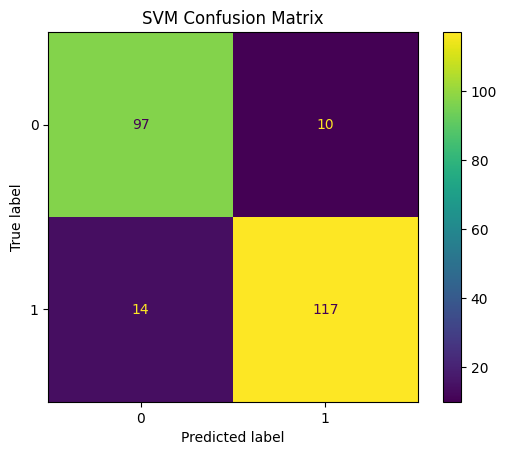

LogisticRegression Classifier:
Best Parameters: {'C': 1}
Accuracy: 0.8613445378151261
              precision    recall  f1-score   support

           0       0.85      0.84      0.85       107
           1       0.87      0.88      0.87       131

    accuracy                           0.86       238
   macro avg       0.86      0.86      0.86       238
weighted avg       0.86      0.86      0.86       238



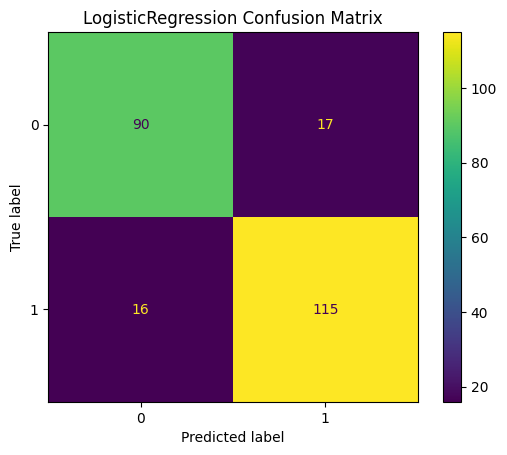

DecisionTree Classifier:
Best Parameters: {'criterion': 'gini', 'max_depth': 10}
Accuracy: 0.8991596638655462
              precision    recall  f1-score   support

           0       0.87      0.92      0.89       107
           1       0.93      0.89      0.91       131

    accuracy                           0.90       238
   macro avg       0.90      0.90      0.90       238
weighted avg       0.90      0.90      0.90       238



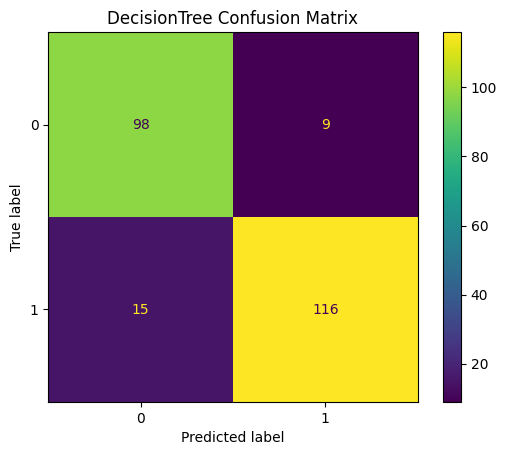

RandomForest Classifier:
Best Parameters: {'criterion': 'gini', 'max_depth': 20, 'n_estimators': 100}
Accuracy: 0.9495798319327731
              precision    recall  f1-score   support

           0       0.95      0.93      0.94       107
           1       0.95      0.96      0.95       131

    accuracy                           0.95       238
   macro avg       0.95      0.95      0.95       238
weighted avg       0.95      0.95      0.95       238



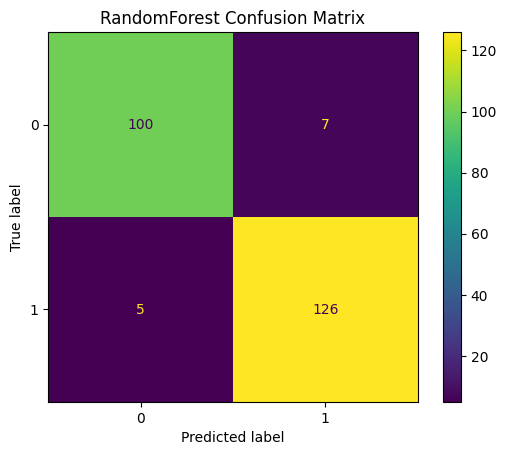

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Voting Classifier:
Accuracy: 0.9201680672268907
              precision    recall  f1-score   support

           0       0.90      0.93      0.91       107
           1       0.94      0.92      0.93       131

    accuracy                           0.92       238
   macro avg       0.92      0.92      0.92       238
weighted avg       0.92      0.92      0.92       238



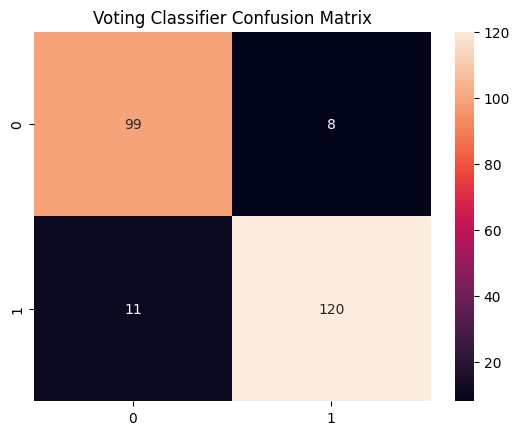

In [24]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay # Changed here
import matplotlib.pyplot as plt
import seaborn as sns


data = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')
X = data.drop('target', axis=1)
y = data['target']


X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


models_params = {
    'SVM': {
        'model': SVC(probability=True),
        'params': {'kernel': ['linear', 'rbf'], 'C': [1, 10, 20]}
    },
    'LogisticRegression': {
        'model': LogisticRegression(),
        'params': {'C': [1, 5, 10]}
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 20]}
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {'n_estimators': [10, 50, 100], 'criterion': ['gini', 'entropy'], 'max_depth': [5, 10, 20]}
    }
}


trained_models = []
for name, mp in models_params.items():
    pipe = Pipeline(
        [
            ('scaler', StandardScaler()),
            (name, GridSearchCV(mp['model'], mp['params'], cv=5))
        ]
    )
    pipe.fit(X_train, y_train)


    predictions = pipe.predict(X_test)
    print(f"{name} Classifier:")
    print(f"Best Parameters: {pipe.named_steps[name].best_params_}")
    print(f"Accuracy: {accuracy_score(y_test, predictions)}")
    print(classification_report(y_test, predictions))
    ConfusionMatrixDisplay.from_estimator(pipe, X_test, y_test)
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    trained_models.append(pipe.named_steps[name].best_estimator_)


voting_classifier = VotingClassifier(estimators=[(name, model) for name, model in zip(models_params.keys(), trained_models)], voting='soft')
voting_classifier.fit(X_train, y_train)


voting_predictions = voting_classifier.predict(X_test)
print("Voting Classifier:")
print(f"Accuracy: {accuracy_score(y_test, voting_predictions)}")
print(classification_report(y_test, voting_predictions))
conf_matrix = confusion_matrix(y_test, voting_predictions)
sns.heatmap(conf_matrix, annot=True, fmt="d")
plt.title("Voting Classifier Confusion Matrix")
plt.show()

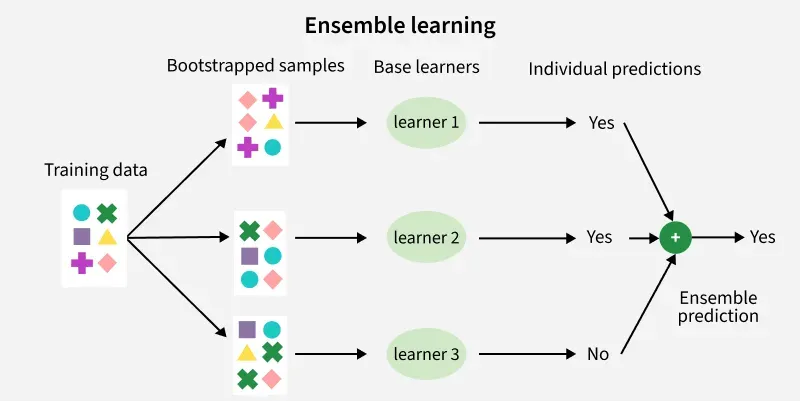

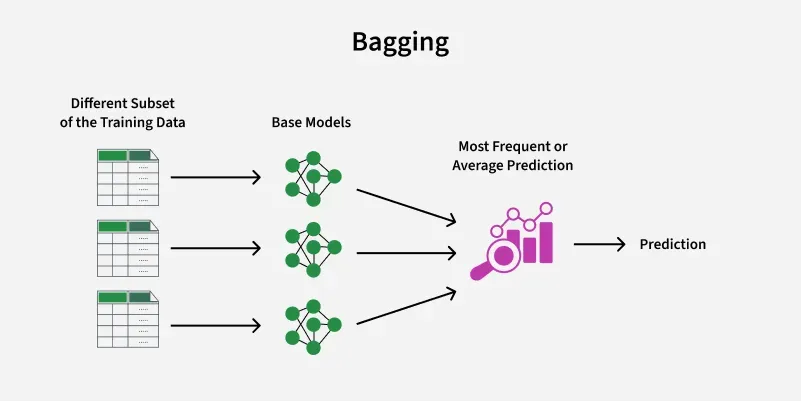

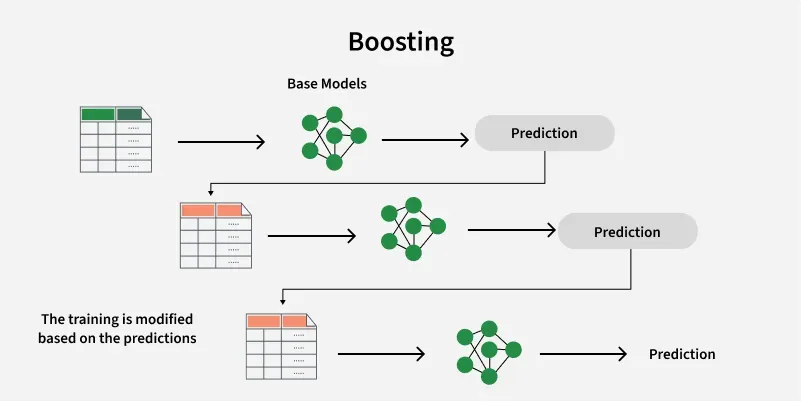

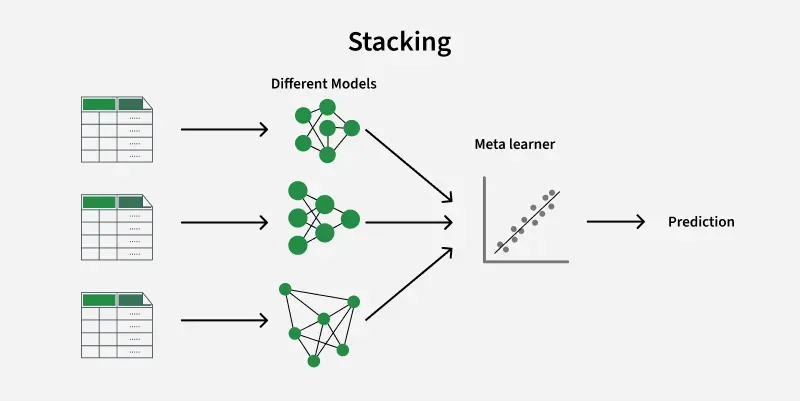

In [25]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier


from sklearn.ensemble import VotingClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import StackingClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix


data = pd.read_csv('/content/heart_statlog_cleveland_hungary_final.csv')

X = data.drop('target', axis=1)
y = data['target']


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


svm = SVC(kernel='linear', probability=True)
log_reg = LogisticRegression()
dt = DecisionTreeClassifier()
rf = RandomForestClassifier()


voting_clf = VotingClassifier(
    estimators=[
        ('svm', svm),
        ('lr', log_reg),
        ('dt', dt)
    ],
    voting='hard'
)

voting_clf.fit(X_train, y_train)
voting_pred = voting_clf.predict(X_test)

print("\nVoting Classifier")
print("Accuracy:", accuracy_score(y_test, voting_pred))
print(confusion_matrix(y_test, voting_pred))



bagging = BaggingClassifier(
    estimator=DecisionTreeClassifier(),
    n_estimators=50,
    random_state=42
)

bagging.fit(X_train, y_train)
bagging_pred = bagging.predict(X_test)

print("\nBagging Classifier")
print("Accuracy:", accuracy_score(y_test, bagging_pred))
print(confusion_matrix(y_test, bagging_pred))



adaboost = AdaBoostClassifier(
    estimator=DecisionTreeClassifier(max_depth=1),
    n_estimators=50,
    random_state=42,
    algorithm='SAMME'
)

adaboost.fit(X_train, y_train)
boost_pred = adaboost.predict(X_test)

print("\nAdaBoost Classifier")
print("Accuracy:", accuracy_score(y_test, boost_pred))
print(confusion_matrix(y_test, boost_pred))


stacking = StackingClassifier(
    estimators=[
        ('svm', svm),
        ('rf', rf),
        ('dt', dt)
    ],
    final_estimator=LogisticRegression()
)

stacking.fit(X_train, y_train)
stack_pred = stacking.predict(X_test)

print("\nStacking Classifier")
print("Accuracy:", accuracy_score(y_test, stack_pred))
print(confusion_matrix(y_test, stack_pred))


Voting Classifier
Accuracy: 0.865546218487395
[[ 91  16]
 [ 16 115]]

Bagging Classifier
Accuracy: 0.9411764705882353
[[100   7]
 [  7 124]]

AdaBoost Classifier
Accuracy: 0.8781512605042017
[[ 90  17]
 [ 12 119]]


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(



Stacking Classifier
Accuracy: 0.9495798319327731
[[100   7]
 [  5 126]]
